# **ESTUDO DE CASO: MÉTODOS DE PROJEÇÃO**
##### **Case**: *Potencial de Novos Clientes* <br> **Base de Dados**: *Potencial_Novos_Clientes.txt*
--------------

### **INSTALAÇÃO/CARREGAMENTO DE BIBLIOTECAS**

In [ ]:
import pandas as pd                                                                # Manipulação de dados
import numpy as np                                                                 # Realização de cálculos específicos
import matplotlib.pyplot as plt                                                    # Visualização de dados
import seaborn as sns                                                              # Visualização de dados
import time                                                                        # Cálculo de tempo de execução
import math                                                                        # Funções matemáticas
import statsmodels.api as sm                                                       # Ajuste de modelos de regressão
from statsmodels.stats.outliers_influence import variance_inflation_factor         # Cálculo do VIF
from sklearn.preprocessing import OneHotEncoder                                    # Codificação one-hot
from scipy.stats import randint, uniform, loguniform                               # Geração de valores aleatórios
from sklearn.compose import ColumnTransformer                                      # Transformação de colunas
from sklearn.preprocessing import StandardScaler, OneHotEncoder                    # Transformação de colunas
from sklearn.base import clone                                                     # Criação de cópias de modelos
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV    # Validação simples e validação cruzada
from sklearn.metrics import r2_score, root_mean_squared_error                      # Métricas de avaliação de modelos
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor            # Regressão linear com regularização
from sklearn.tree import DecisionTreeRegressor                                     # Árvore de regressão
from sklearn.ensemble import RandomForestRegressor                                 # Floresta aleatória
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor          # Impulsionamento tradicional
from sklearn.ensemble import HistGradientBoostingRegressor                         # Impulsionamento com histogramas
from xgboost import XGBRegressor                                                   # Impulsionamento via XGBoost
from lightgbm import LGBMRegressor                                                 # Impulsionamento via LightGBM
from sklearn.inspection import permutation_importance                              # Importância de variáveis por permutação
import shap                                                                        # Interpretabilidade de variáveis nos modelos

In [ ]:
! pip install shap

### **LEITURA DA BASE DE DADOS**

In [ ]:
dados = pd.read_table("Potencial_Novos_Clientes.txt",  # Substitua pelo nome da base de dados
                      sep="\t",                        # Ajuste o separador de colunas, se necessário
                      decimal=".",                     # Ajuste o separador de decimal, se necessário
                      header=0)

#### **Visualização, Dimensões e Tipos das colunas da base de dados**

In [ ]:
dados.head()

,COD_CARTAO,IDADE_CLIENTE,RENDA_MENSAL_CLIENTE,BEHAVIOUR_SCORE_CLIENTE,QTD_TRANSACOES_3M,QTD_ITENS_3M,VALOR_GASTO_3M,TICKET_MEDIO_3M,FLAG_ALTO_CUSTO_3M,SATISFACAO_CARTAO,VALOR_GASTO_PROX_12M
0,212394,22,1500,52,2,4,802,401.00,0,01_Muito_Satisfeito,226
1,279177,29,1800,94,5,5,1384,276.80,1,03_Neutro,2786
2,291430,36,1500,89,5,6,1610,322.00,1,Nao_Respondeu,3737
3,176612,43,1500,48,3,4,836,278.67,0,01_Muito_Satisfeito,1162
4,223092,28,12090,89,4,5,1318,329.50,0,Nao_Respondeu,2699


In [ ]:
dados.shape

(2930, 11)

In [ ]:
dados.dtypes

,0
COD_CARTAO,int64
IDADE_CLIENTE,int64
RENDA_MENSAL_CLIENTE,int64
BEHAVIOUR_SCORE_CLIENTE,int64
QTD_TRANSACOES_3M,int64
QTD_ITENS_3M,int64
VALOR_GASTO_3M,int64
TICKET_MEDIO_3M,float64
FLAG_ALTO_CUSTO_3M,int64
SATISFACAO_CARTAO,object


### **Etapa 1: Tratamento de valores ausentes, especificação de variáveis e análise bivariada**

In [ ]:
# Verificando a quantidade de valores ausentes
dados.isna().sum()

,0
COD_CARTAO,0
IDADE_CLIENTE,0
RENDA_MENSAL_CLIENTE,0
BEHAVIOUR_SCORE_CLIENTE,0
QTD_TRANSACOES_3M,0
QTD_ITENS_3M,0
VALOR_GASTO_3M,0
TICKET_MEDIO_3M,0
FLAG_ALTO_CUSTO_3M,0
SATISFACAO_CARTAO,0


*Lista de nomes das variáveis explicativas, separando em quantitativas e qualitativas*

In [ ]:
# Variáveis explicativas quantitativas (deixar vazio [] caso não haja nenhuma)
lista_X_quanti = ['IDADE_CLIENTE',
                  'RENDA_MENSAL_CLIENTE',
                  'BEHAVIOUR_SCORE_CLIENTE',
                  'QTD_TRANSACOES_3M',
                  'QTD_ITENS_3M',
                  'VALOR_GASTO_3M',
                  'TICKET_MEDIO_3M']

# Variáveis explicativas qualitativas (deixar vazio [] caso não haja nenhuma)
lista_X_quali = ['FLAG_ALTO_CUSTO_3M',
                 'SATISFACAO_CARTAO']

*Objetos para variável resposta (y) e explicativas (X)*

In [ ]:
y = dados['VALOR_GASTO_PROX_12M']
X = dados[lista_X_quanti + lista_X_quali]

### **QUESTÃO 1**

*Análise bivariada: gráficos de boxplot para variáveis explicativas qualitativas versus variável resposta*

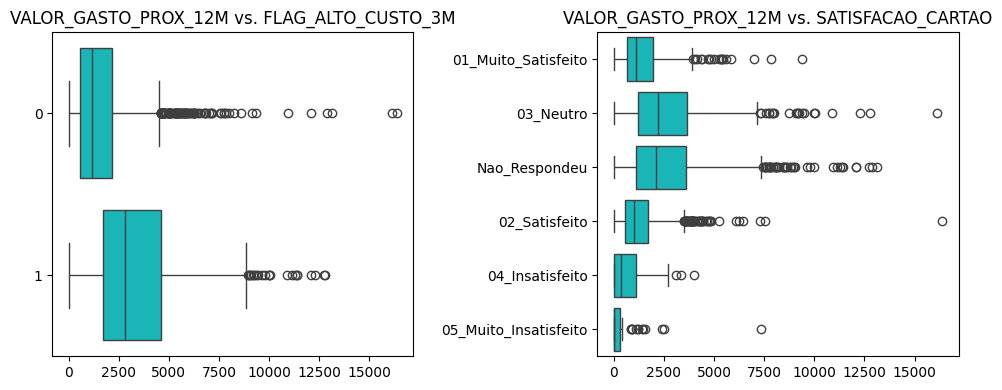

In [ ]:
if lista_X_quali:
    n = len(lista_X_quali)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows,
                             ncols=ncols,
                             figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(lista_X_quali):
        sns.boxplot(y=dados[var],
                    x=y,
                    ax=axes[i],
                    orient='h',
                    color='darkturquoise')
        axes[i].set_title(f'{y.name} vs. {var}')
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout(h_pad=2, w_pad=2)
    plt.show()

*Análise bivariada: gráficos de dispersão para variáveis explicativas quantitativas versus variável resposta*

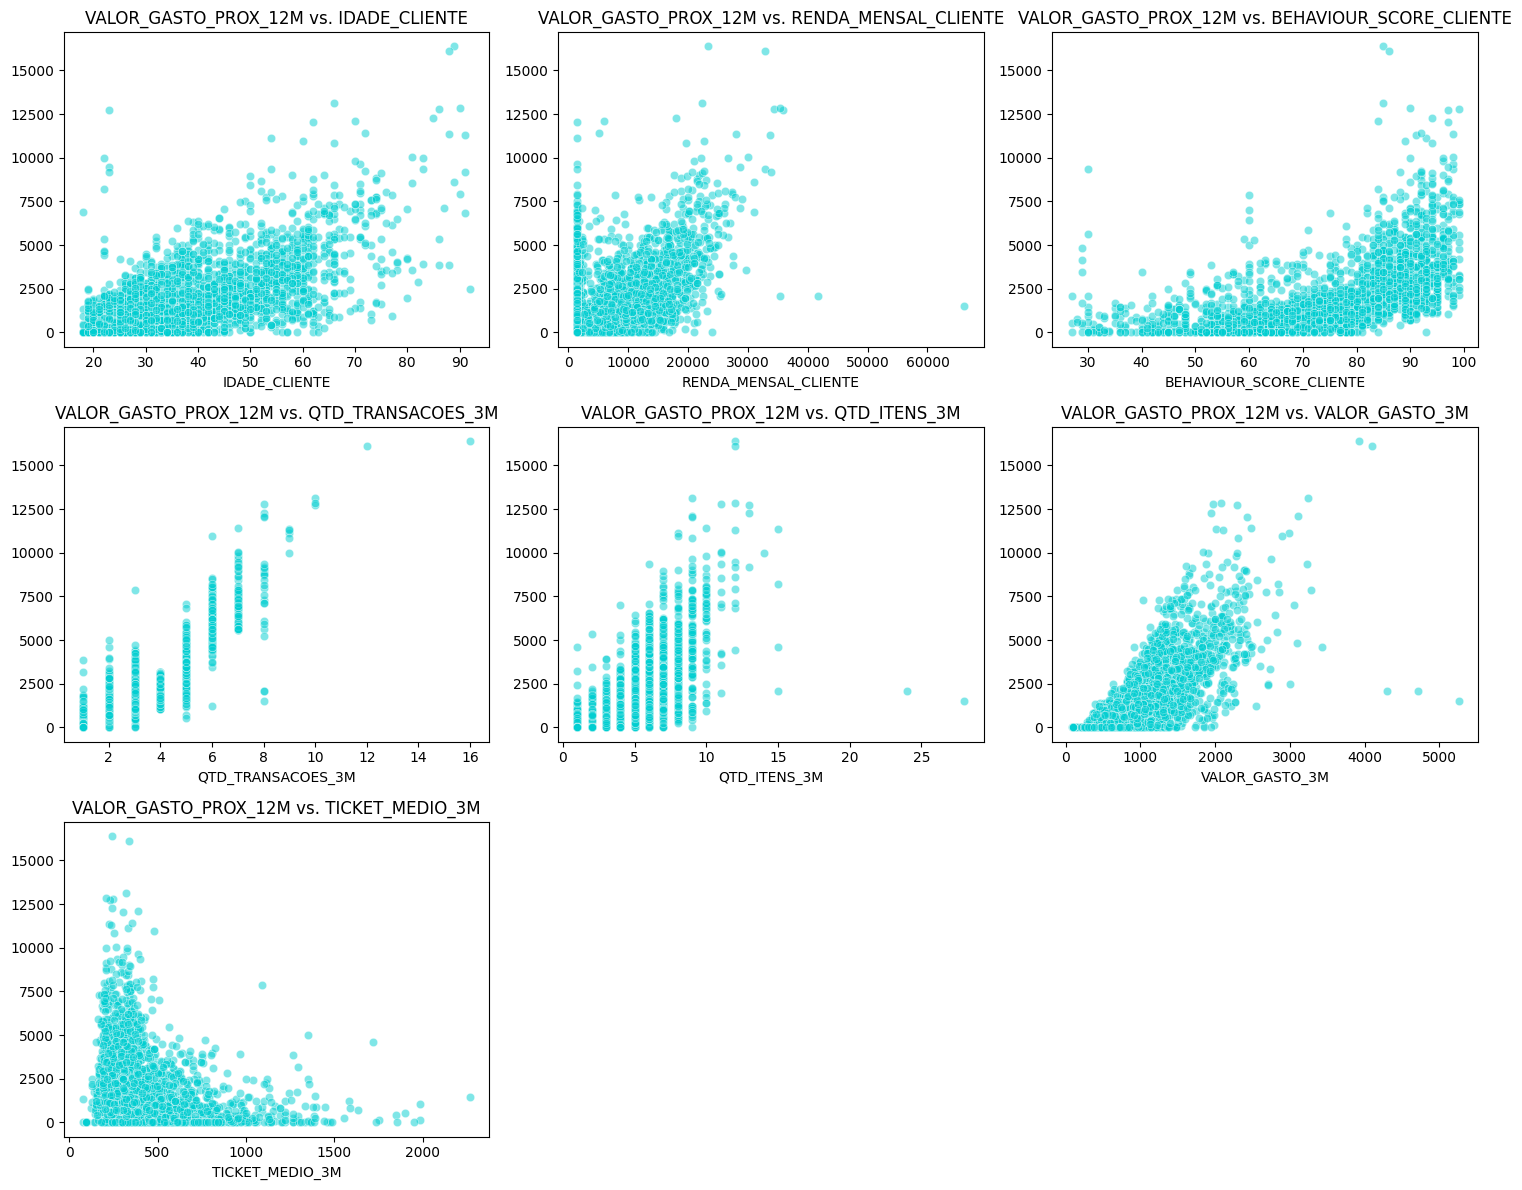

In [ ]:
if lista_X_quanti:
    n = len(lista_X_quanti)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows=nrows,
                             ncols=ncols,
                             figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(lista_X_quanti):
        sns.scatterplot(x=dados[var],
                        y=y,
                        ax=axes[i],
                        color='darkturquoise',
                        alpha=0.5)
        axes[i].set_title(f'{y.name} vs. {var}')
        axes[i].set_ylabel("")

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    plt.show()

#### Conclusão

*Interpretação Variáveis qualitativas*

1) FLAG_ALTO_CUSTO_3M vs. VALOR_GASTO_PROX_12M

Clientes que realizaram pelo menos uma compra de alto custo nos primeiros 3 meses (flag = 1) tendem a apresentar um valor maior de gasto nos 12 meses seguintes. A mediana desse grupo é mais alta em comparação aos que não realizaram esse tipo de compra, além de apresentarem maior dispersão, o que pode indicar a existência de diferentes perfis de consumo dentro desse grupo.

2) SATISFACAO_CARTAO vs. VALOR_GASTO_PROX_12

Ao contrário do esperado, clientes "Muito Satisfeitos" ou "Satisfeitos" apresentaram medianas de gasto inferiores às observadas nos grupos "Neutro" e "Não Respondeu". Isso sugere que a satisfação declarada pode não estar necessariamente associada a um maior consumo ao longo dos 12 meses. A maior dispersão nesses dois últimos grupos pode refletir perfis que utilizam o cartão de forma mais intensa, ainda que sem forte engajamento emocional. Já os clientes "Insatisfeitos" e "Muito Insatisfeitos" apresentam os menores níveis de gasto, indicando que a insatisfação explícita tende a refletir em uma menor utilização do cartão/consumo.

*Interpretação Variáveis quantitativas*

1) IDADE_CLIENTE vs. VALOR_GASTO_PROX_12M

A relação entre idade e gasto futuro apresenta grande dispersão. Nota-se uma leve tendência de que clientes mais velhos gastem mais, embora existam clientes mais jovens com altos gastos.

2) RENDA_MENSAL_CLIENTE vs. VALOR_GASTO_PROX_12M

De maneira geral, quanto maior a renda, maior o gasto. Entretanto, há clientes com renda baixa que gastam muito e outros com renda alta que gastam pouco. Curiosamente, faixas intermediárias de renda, em alguns casos, apresentam menor gasto do que faixas mais baixas. Além disso, a presença de outliers e a possibilidade de subdeclaração da renda podem comprometer a confiabilidade dessa variável.

3) BEHAVIOUR_SCORE_CLIENTE vs. VALOR_GASTO_PROX_12M

Clientes com behavior score mais elevado tendem a apresentar um maior gasto nos próximos 12 meses. Entretanto, vale ressaltar que a relação não é perfeitamente linear, uma vez que existem clientes com um behavior baixo e que gastam bastante.

4) QTD_TRANSACOES_3M vs. VALOR_GASTO_PROX_12M

Há uma correlação positiva entre a quantidade de transações nos primeiros 3 meses e o valor gasto posteriormente. Clientes mais ativos desde o início (maiores transações) tendem a manter um padrão de consumo mais elevado ao longo do tempo.

4) QTD_ITENS_3M vs. VALOR_GASTO_PROX_12M

Assim como nas transações, observa-se uma relação positiva entre a quantidade de itens comprados e o gasto futuro. Clientes que adquiriram mais itens nos primeiros meses tendem a manter um alto volume de compras posteriormente.

5) VALOR_GASTO_3M vs. VALOR_GASTO_PROX_12M

Há uma forte correlação entre o valor gasto nos primeiros 3 meses e o valor gasto nos 12 meses seguintes. Clientes que já demonstram um padrão de consumo elevado no início tendem a manter esse comportamento no longo prazo.

6) TICKET_MEDIO_3M vs. VALOR_GASTO_PROX_12M

Não se observa uma tendência clara entre o ticket médio inicial e o gasto futuro. A alta dispersão dos dados indica que valores médios de compra mais altos não garantem maior consumo total. Por outro lado, clientes com tickets baixos podem, ainda assim, ter um alto gasto acumulado, reforçando que o ticket médio, isoladamente, possui baixo poder explicativo.

### **QUESTÃO 2**

*Análise bivariada: matriz de correlações lineares de Pearson para variáveis explicativas quantitativas*

In [ ]:
matriz_cor = (pd.concat([dados[lista_X_quanti], y], axis=1)).corr().round(3)
matriz_cor

,IDADE_CLIENTE,RENDA_MENSAL_CLIENTE,BEHAVIOUR_SCORE_CLIENTE,QTD_TRANSACOES_3M,QTD_ITENS_3M,VALOR_GASTO_3M,TICKET_MEDIO_3M,VALOR_GASTO_PROX_12M
IDADE_CLIENTE,1.000,0.386,0.325,0.518,0.720,0.470,-0.046,0.609
RENDA_MENSAL_CLIENTE,0.386,1.000,0.294,0.350,0.520,0.198,-0.205,0.437
BEHAVIOUR_SCORE_CLIENTE,0.325,0.294,1.000,0.601,0.424,0.217,-0.489,0.538
QTD_TRANSACOES_3M,0.518,0.350,0.601,1.000,0.583,0.638,-0.505,0.888
QTD_ITENS_3M,0.720,0.520,0.424,0.583,1.000,0.440,-0.214,0.622
VALOR_GASTO_3M,0.470,0.198,0.217,0.638,0.440,1.000,0.197,0.702
TICKET_MEDIO_3M,-0.046,-0.205,-0.489,-0.505,-0.214,0.197,1.000,-0.294
VALOR_GASTO_PROX_12M,0.609,0.437,0.538,0.888,0.622,0.702,-0.294,1.000


*Análise bivariada: gráfico de calor para representar a matriz de correlações*

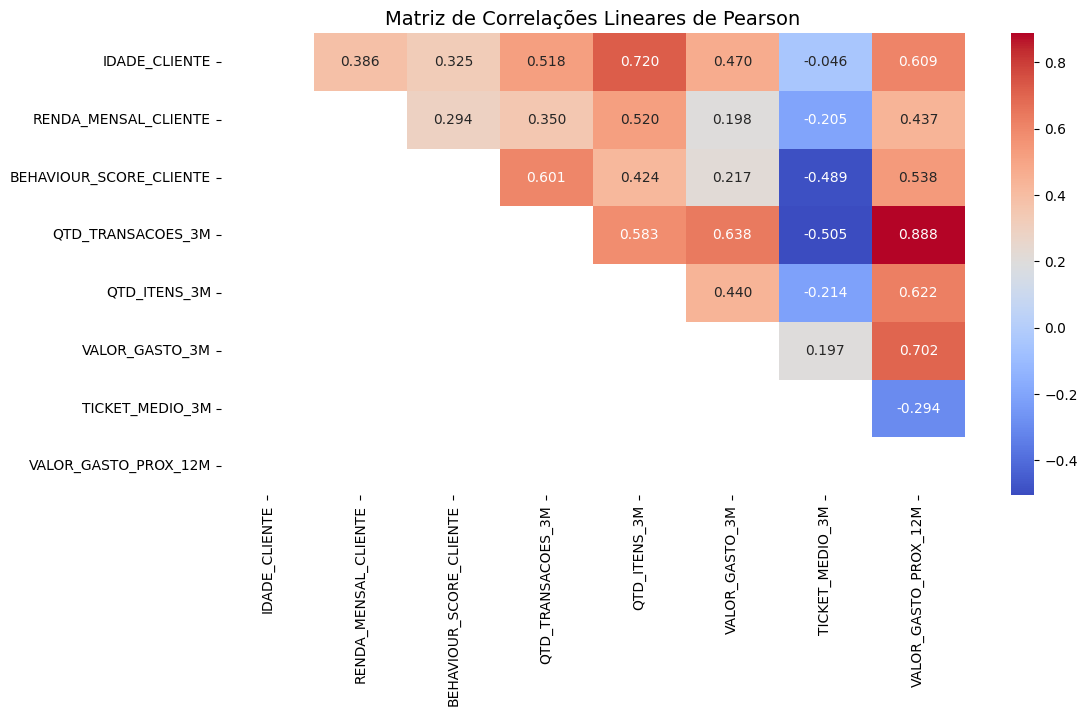

In [ ]:
mask = np.tril(np.ones(matriz_cor.shape, dtype=bool))

plt.figure(figsize=(12, 6))
sns.heatmap(matriz_cor, mask=mask, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Matriz de Correlações Lineares de Pearson", fontsize=14)
plt.show()

#### Conclusão

*(a) Quais as duas variáveis explicativas mais correlacionadas com a variável resposta?*

Tendo em vista que a variável resposta é o VALOR_GASTO_PROX_12M, as duas variáveis explicativas mais correlacionadas com ela são QTD_TRANSACOES_3M e VALOR_GASTO_3M, com coeficientes de correlação de 0.888 e 0.702, respectivamente. Ambas as correlações são coerentes do ponto de vista de negócio, já que os clientes que realizam mais transações nos primeiros meses demonstram maior engajamento e familiaridade com o cartão, o que tende a se refletir em um maior consumo ao longo do tempo. Da mesma forma, clientes que apresentam um alto valor de gasto logo no início podem indicar um comportamento de consumo consistente, o que naturalmente se mantém nos meses seguintes.


*(b) Quais as duas variáveis explicativas menos correlacionadas com a variável
resposta?*

As duas variáveis menos correlacionadas com a variável resposta são TICKET_MEDIO_3M (-0.294) e RENDA_MENSAL_CLIENTE (0.437). Essa baixa correlação é coerente no contexto de negócio. Um ticket médio alto pode indicar poucas compras pontuais e não necessariamente um padrão de consumo frequente. Já a renda mensal, embora importante, nem sempre reflete o uso real do cartão, pois clientes de maior renda podem optar por outros meios de pagamento, enquanto clientes de menor renda podem usar mais intensamente o cartão por necessidade. Um ponto importante a se destacar é que os clientes podem ter informado uma renda inferior a real, com receio na exposição dos dados, o que poderia diminuir a correlação.

*(c) Quais as duas variáveis explicativas mais correlacionadas entre si?*

As duas variáveis explicativas mais correlacionadas entre si são IDADE_CLIENTE e QTD_ITENS_3M, com um coeficiente de correlação de 0.720. Essa forte correlação indica que, na base analisada, clientes com maior idade tendem a realizar mais transações nos três primeiros meses de uso do cartão. Do ponto de vista de negócio, isso pode sugerir que clientes mais velhos apresentam maior propensão a utilizar o cartão com frequência, seja por confiança na marca, hábito de parcelamento ou perfil de consumo/renda mais consolidado.

### **QUESTÃO 3**

*Definição da função de pré-processamento: Codificação one-hot para variáveis qualitativas*

In [ ]:
preprocessador = ColumnTransformer(transformers=[
    ("quali", OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore'), lista_X_quali)
],
    remainder='passthrough'
)

*Criação e aplicação do pré-processamento*

In [ ]:
X_tratada = preprocessador.fit_transform(X)
if lista_X_quali:
    nomes_quali = list(preprocessador.named_transformers_['quali'].get_feature_names_out(lista_X_quali))
else:
    nomes_quali = []
nomes_variaveis = nomes_quali + list(lista_X_quanti)

In [ ]:
X_tratada = pd.DataFrame(X_tratada, columns=nomes_variaveis)
X_tratada.head()

,FLAG_ALTO_CUSTO_3M_1,SATISFACAO_CARTAO_02_Satisfeito,SATISFACAO_CARTAO_03_Neutro,SATISFACAO_CARTAO_04_Insatisfeito,SATISFACAO_CARTAO_05_Muito_Insatisfeito,SATISFACAO_CARTAO_Nao_Respondeu,IDADE_CLIENTE,RENDA_MENSAL_CLIENTE,BEHAVIOUR_SCORE_CLIENTE,QTD_TRANSACOES_3M,QTD_ITENS_3M,VALOR_GASTO_3M,TICKET_MEDIO_3M
0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,1500.0,52.0,2.0,4.0,802.0,401.00
1,1.0,0.0,1.0,0.0,0.0,0.0,29.0,1800.0,94.0,5.0,5.0,1384.0,276.80
2,1.0,0.0,0.0,0.0,0.0,1.0,36.0,1500.0,89.0,5.0,6.0,1610.0,322.00
3,0.0,0.0,0.0,0.0,0.0,0.0,43.0,1500.0,48.0,3.0,4.0,836.0,278.67
4,0.0,0.0,0.0,0.0,0.0,1.0,28.0,12090.0,89.0,4.0,5.0,1318.0,329.50


##### **Etapa 3: Construção do modelo de regressão linear**

*Ajuste do modelo 1*

In [ ]:
modelo_1 = sm.OLS(y, sm.add_constant(X_tratada)).fit()
print(modelo_1.summary(alpha=0.03))

                             OLS Regression Results                             
Dep. Variable:     VALOR_GASTO_PROX_12M   R-squared:                       0.857
Model:                              OLS   Adj. R-squared:                  0.857
Method:                   Least Squares   F-statistic:                     1349.
Date:                  Tue, 05 Aug 2025   Prob (F-statistic):               0.00
Time:                          00:53:02   Log-Likelihood:                -23499.
No. Observations:                  2930   AIC:                         4.703e+04
Df Residuals:                      2916   BIC:                         4.711e+04
Df Model:                            13                                         
Covariance Type:              nonrobust                                         
                                              coef    std err          t      P>|t|      [0.015      0.985]
----------------------------------------------------------------------------------

*Ajuste do modelo 2*

In [ ]:
# Excluindo a variável 'QTD_ITENS_3M' pois tem p-valor > 0.03
X_tratada = X_tratada.drop(['QTD_ITENS_3M'], axis=1)

In [ ]:
modelo_2 = sm.OLS(y, sm.add_constant(X_tratada)).fit()
print(modelo_2.summary())

                             OLS Regression Results                             
Dep. Variable:     VALOR_GASTO_PROX_12M   R-squared:                       0.857
Model:                              OLS   Adj. R-squared:                  0.857
Method:                   Least Squares   F-statistic:                     1461.
Date:                  Tue, 05 Aug 2025   Prob (F-statistic):               0.00
Time:                          00:53:28   Log-Likelihood:                -23499.
No. Observations:                  2930   AIC:                         4.702e+04
Df Residuals:                      2917   BIC:                         4.710e+04
Df Model:                            12                                         
Covariance Type:              nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

*Ajuste do modelo 3*

In [ ]:
# Excluindo a variável 'SATISFACAO_CARTAO_02_Satisfeito' pois tem p-valor > 0.03
X_tratada = X_tratada.drop(['SATISFACAO_CARTAO_02_Satisfeito'], axis=1)

In [ ]:
modelo_3 = sm.OLS(y, sm.add_constant(X_tratada)).fit()
print(modelo_3.summary())

                             OLS Regression Results                             
Dep. Variable:     VALOR_GASTO_PROX_12M   R-squared:                       0.857
Model:                              OLS   Adj. R-squared:                  0.857
Method:                   Least Squares   F-statistic:                     1593.
Date:                  Tue, 05 Aug 2025   Prob (F-statistic):               0.00
Time:                          00:54:02   Log-Likelihood:                -23500.
No. Observations:                  2930   AIC:                         4.702e+04
Df Residuals:                      2918   BIC:                         4.710e+04
Df Model:                            11                                         
Covariance Type:              nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

*Ajuste do modelo 4*

In [ ]:
# Excluindo a variável 'SATISFACAO_CARTAO_04_Insatisfeito' pois tem p-valor > 0.03
X_tratada = X_tratada.drop(['SATISFACAO_CARTAO_04_Insatisfeito'], axis=1)

In [ ]:
modelo_4 = sm.OLS(y, sm.add_constant(X_tratada)).fit()
print(modelo_4.summary())

                             OLS Regression Results                             
Dep. Variable:     VALOR_GASTO_PROX_12M   R-squared:                       0.857
Model:                              OLS   Adj. R-squared:                  0.857
Method:                   Least Squares   F-statistic:                     1751.
Date:                  Tue, 05 Aug 2025   Prob (F-statistic):               0.00
Time:                          00:54:16   Log-Likelihood:                -23502.
No. Observations:                  2930   AIC:                         4.703e+04
Df Residuals:                      2919   BIC:                         4.709e+04
Df Model:                            10                                         
Covariance Type:              nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

#### Conclusão

Após a implementação do stepwise backward, todas as variáveis que permaneceram no modelo apresentaram p-valor ≤ 0,03, sendo, portanto, estatisticamente significativas ao nível de 3%. O modelo final explica aproximadamente 85,7% da variação no gasto dos clientes nos 12 meses seguintes, o que indica um ótimo ajuste. A seguir, apresenta-se a interpretação dos coeficientes estimados:

O intercepto (const = -2.860,36) representa o valor estimado do gasto futuro para um cliente com valor zero em todas as variáveis explicativas, o que tem pouca aplicabilidade prática, mas é necessário para a estruturação do modelo. Ou seja, referem-se aos clientes novos, os quais teriam após os 3 primeiros meses, teriam um gasto futuro negativo.

A variável FLAG_ALTO_CUSTO_3M_1 indica que clientes que realizaram pelo menos uma compra em estabelecimento de alto custo nos três primeiros meses tendem a gastar, em média, R$247,44 a mais nos 12 meses seguintes em relação aos que não tiveram alto custo se mantidas as demais características fixas.

A variável SATISFACAO_CARTAO_03_Neutro mostra que clientes com satisfação neutra gastam, em média R$106,98 a menos nos próximos 12 meses do que o grupo base de clientes retirados ("Muito Satisfeitos", "SATISFACAO_CARTAO_02_Satisfeito" e "SATISFACAO_CARTAO_04_Insatisfeito"). De forma semelhante, a SATISFACAO_CARTAO_05_Muito_Insatisfeito indica que tendem a gastar 225,51 reais a menos e SATISFACAO_CARTAO_NAO_RESPONDEU revela que quem não respondeu tende a gastar 125,49 reais a menos também em comparação aos grupos retirados ("Muito Satisfeitos", "SATISFACAO_CARTAO_02_Satisfeito" e "SATISFACAO_CARTAO_04_Insatisfeito") se mantidas as demais características fixas.

Analisando a IDADE_CLIENTE, verifica-se que a cada aumento de 1 ano na idade, espera-se um aumento médio de 15,92 reais nos próximos 12 meses gasto futuro. A RENDA_MENSAL_CLIENTE relata que a cada 1 real a mais de renda mensal declarada, o gasto previsto aumenta, em média, 0,036 reais. O BEHAVIOUR_SCORE_CLIENTE  cada 1 ponto a mais no behaviour score, o gasto previsto aumenta, em média, 6,76 reais. Em QTD_TRANSACOES_3M, a cada transação adicional nos primeiros 3 meses, o cliente tende a gastar, em média, R$795,98 a mais nos 12 meses seguintes. O VALOR_GASTO_3M relata que cada 1,00 real gasto nos primeiros 3 meses, espera-se um aumento de 0,59 reais no gasto futuro. Por fim, TICKET_MEDIO_3M A cada 1 real de aumento no ticket médio, o valor futuro previsto aumenta a cada 0,75 reais, em média. Lembrando que, toda a analise feita acima em relação aos coeficientes leva em consideração se são mantidas fixas as demais características.


### **QUESTÃO 4**

In [ ]:
modelo = modelo_4    # Digite o nome do objeto do modelo que deseja avaliar
vif = pd.DataFrame({
    "Variável": modelo.model.exog_names,
    "VIF": [variance_inflation_factor(modelo.model.exog, i) for i in range(modelo.model.exog.shape[1])]
})

print(vif)

                                   Variável        VIF
0                                     const  65.612346
1                      FLAG_ALTO_CUSTO_3M_1   1.442055
2               SATISFACAO_CARTAO_03_Neutro   1.568081
3   SATISFACAO_CARTAO_05_Muito_Insatisfeito   1.084742
4           SATISFACAO_CARTAO_Nao_Respondeu   1.707618
5                             IDADE_CLIENTE   1.633674
6                      RENDA_MENSAL_CLIENTE   1.288147
7                   BEHAVIOUR_SCORE_CLIENTE   2.375379
8                         QTD_TRANSACOES_3M   7.655327
9                            VALOR_GASTO_3M   4.610813
10                          TICKET_MEDIO_3M   3.920868


#### Conclusão

A análise dos índices VIF revela indícios de colinearidade entre algumas variáveis explicativas do modelo 4. Adotando um critério conservador, em que valores próximos, iguais ou superiores a 2 já são considerados colineares, observou-se esse comportamento de forma mais acentuada em variáveis como QTD_TRANSACOES_3M (7,66), VALOR_GASTO_3M (4,61), TICKET_MEDIO_3M (3,92) e BEHAVIOUR_SCORE_CLIENTE (2,38). Além disso, variáveis como IDADE_CLIENTE (1,63) e SATISFACAO_CARTAO_Nao_Respondeu (1,71) estão próximas do limite, sugerindo uma possível colinearidade em menor grau.

### **QUESTÃO 5**

*Resíduos do modelo (e)*

In [ ]:
resid = modelo_4.resid   # Altere o nome do objeto do modelo

*Valores preditos pelo modelo (y^)*

In [ ]:
y_hat = modelo_4.predict(sm.add_constant(X_tratada))

*Histograma dos resíduos*

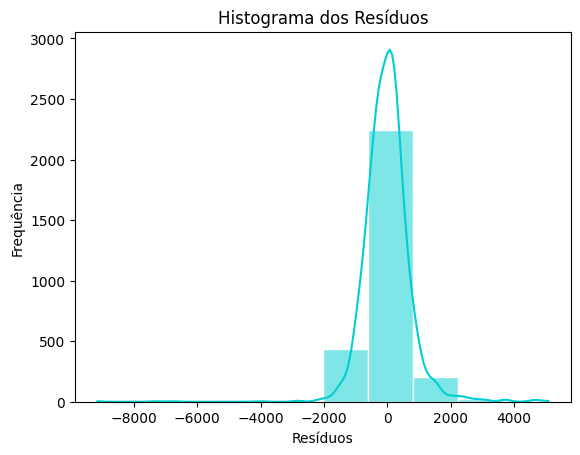

In [ ]:
sns.histplot(resid,
             bins=10,    # Altere a quantidade de bins conforme necessário
             color="darkturquoise",
             edgecolor="white",
             kde=True)
plt.title("Histograma dos Resíduos")
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.show()

*Q-Q plot dos resíduos*

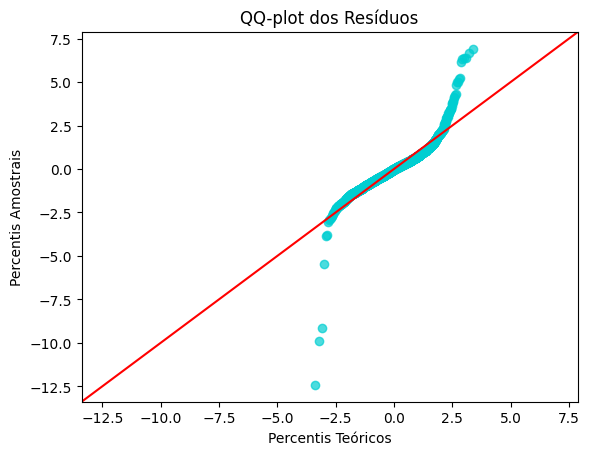

In [ ]:
sm.qqplot(resid,
          line='45',
          fit=True,
          markerfacecolor='darkturquoise',
          markeredgecolor='darkturquoise',
          alpha=0.7)
plt.title("QQ-plot dos Resíduos")
plt.xlabel("Percentis Teóricos")
plt.ylabel("Percentis Amostrais")
plt.show()

*Gráfico de resíduos vs. valores preditos*

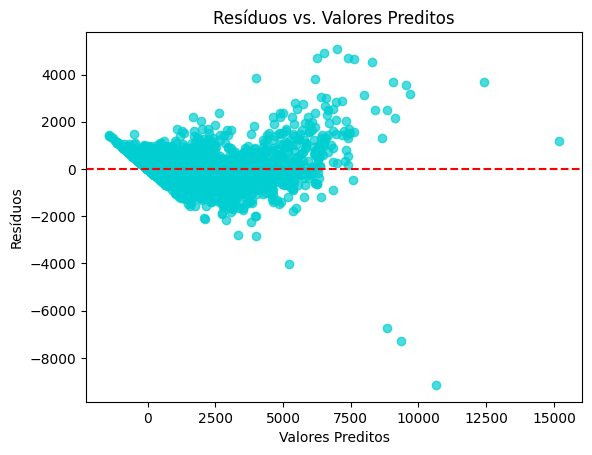

In [ ]:
plt.scatter(y_hat,
            resid,
            color="darkturquoise",
            alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Resíduos vs. Valores Preditos")
plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos")
plt.show()

*Gráfico de valores observados vs. valores preditos da resposta*

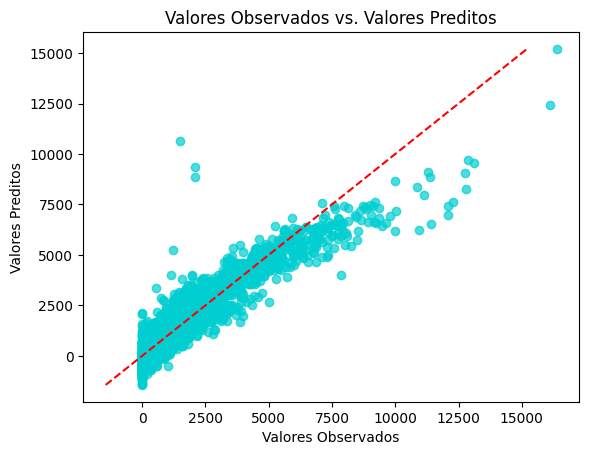

In [ ]:
plt.scatter(y,
            y_hat,
            color="darkturquoise",
            alpha=0.7)
plt.plot([y_hat.min(), y_hat.max()], [y_hat.min(), y_hat.max()], color='red', linestyle='--')
plt.title("Valores Observados vs. Valores Preditos")
plt.xlabel("Valores Observados")
plt.ylabel("Valores Preditos")
plt.show()

*Cálculo das distâncias de Cook*

In [ ]:
influencias = sm.OLS(y, sm.add_constant(X_tratada)).fit().get_influence()
dist_cook = influencias.cooks_distance[0]

*Especificação de limite para identificação de pontos influentes*

In [ ]:
# Limite padrão (4/n)
limite = 4/dados.shape[0]

*Gráfico das distâncias de Cook*

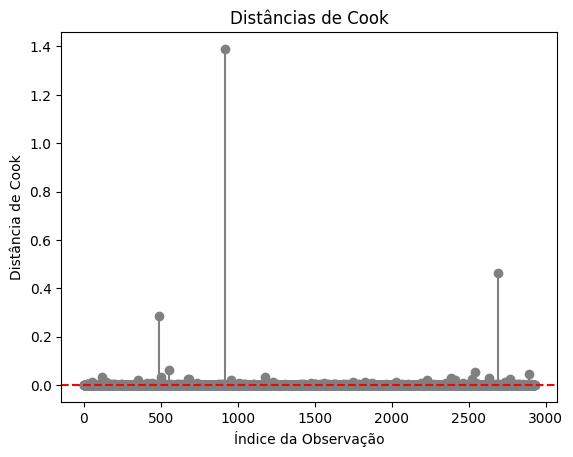

In [ ]:
plt.stem(dist_cook,
         markerfmt="o",
         linefmt="gray",
         basefmt=" ")
plt.axhline(limite,
            color='red',
            linestyle='--')
plt.title("Distâncias de Cook")
plt.xlabel("Índice da Observação")
plt.ylabel("Distância de Cook")
plt.show()

#### Conclusão

O histograma dos resíduos apresenta uma assimetria à esquerda, indicando um possível desvio de normalidade. Essa observação é reforçada pelo QQ-plot, no qual os pontos se afastam da linha de referência principalmente nas extremidades (caudas), sinalizando a presença de outliers e desvio da distribuição normal esperada dos resíduos.

Adicionalmente, o gráfico das distâncias de Cook aponta que, embora a maioria das observações esteja abaixo do limite de influência (linha vermelha), algumas se destacam com valores significativamente mais altos. Isso indica a presença de pontos influentes que podem exercer impacto nos coeficientes estimados do modelo (3 em especifico).

Portanto, os gráficos sugerem que as premissas de normalidade e homocedasticidade dos resíduos não são plenamente atendidas, e que algumas observações influentes merecem atenção em análises futuras.


### **QUESTÃO 6**

#### **Divisão de treino e teste externo**

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y,
                                                        test_size=0.25,
                                                        random_state=123)

#### Pré-processamento de variáveis explicativas

*Definição das funções de pré-processamento: Padronização das variáveis quantitativas + Codificação one-hot para variáveis qualitativas*

In [ ]:
preprocessador = ColumnTransformer(transformers=[
    ("quanti", StandardScaler(), lista_X_quanti),
    ("quali", OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore'), lista_X_quali)
])

*Criação do pré-processamento no conjunto de treino* <br>

In [ ]:
X_treino_tratada = preprocessador.fit_transform(X_treino)  # O pré-processamento não deve envolver o conjunto de teste externo, que deve ficar reservado apenas para aplicações de resultados já obtidos, e nunca construções
if lista_X_quali:
    nomes_quali = list(preprocessador.named_transformers_['quali'].get_feature_names_out(lista_X_quali))
else:
    nomes_quali = []
nomes_variaveis = list(lista_X_quanti) + nomes_quali

In [ ]:
X_treino_tratada = pd.DataFrame(X_treino_tratada, columns=nomes_variaveis)
X_treino_tratada.head()

,IDADE_CLIENTE,RENDA_MENSAL_CLIENTE,BEHAVIOUR_SCORE_CLIENTE,QTD_TRANSACOES_3M,QTD_ITENS_3M,VALOR_GASTO_3M,TICKET_MEDIO_3M,FLAG_ALTO_CUSTO_3M_1,SATISFACAO_CARTAO_02_Satisfeito,SATISFACAO_CARTAO_03_Neutro,SATISFACAO_CARTAO_04_Insatisfeito,SATISFACAO_CARTAO_05_Muito_Insatisfeito,SATISFACAO_CARTAO_Nao_Respondeu
0,-0.184561,-0.958034,-3.211291,-0.670852,-0.739720,0.472931,1.075033,0.0,1.0,0.0,0.0,0.0,0.0
1,1.918628,-0.852028,1.335623,1.662130,1.704872,0.631318,-0.749642,1.0,0.0,1.0,0.0,0.0,0.0
2,0.975819,-0.958034,1.268757,1.078885,1.215954,-0.015917,-0.826792,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.692227,-0.958034,-2.943825,-1.254097,-1.228639,-0.121509,2.626818,0.0,0.0,0.0,1.0,0.0,0.0
4,1.048343,1.438138,0.533227,1.078885,0.727035,1.622703,-0.126713,0.0,0.0,0.0,0.0,0.0,1.0


*Aplicação do pré-processamento no conjunto de teste externo*

In [ ]:
X_teste_tratada = preprocessador.transform(X_teste)  # Note que o mesmo objeto de pré-processamento deve ser utilizado, agora com 'transform' em vez de 'fit_transform'
X_teste_tratada = pd.DataFrame(X_teste_tratada, columns=nomes_variaveis)
X_teste_tratada.head()

,IDADE_CLIENTE,RENDA_MENSAL_CLIENTE,BEHAVIOUR_SCORE_CLIENTE,QTD_TRANSACOES_3M,QTD_ITENS_3M,VALOR_GASTO_3M,TICKET_MEDIO_3M,FLAG_ALTO_CUSTO_3M_1,SATISFACAO_CARTAO_02_Satisfeito,SATISFACAO_CARTAO_03_Neutro,SATISFACAO_CARTAO_04_Insatisfeito,SATISFACAO_CARTAO_05_Muito_Insatisfeito,SATISFACAO_CARTAO_Nao_Respondeu
0,-0.692227,0.364830,-0.068571,-0.670852,-0.250802,-1.157868,-0.666810,0.0,1.0,0.0,0.0,0.0,0.0
1,0.975819,1.321090,0.600093,1.662130,0.727035,2.205411,-0.189244,0.0,0.0,0.0,0.0,0.0,1.0
2,1.193390,1.422679,1.402490,1.078885,1.215954,0.126827,-0.765807,1.0,0.0,1.0,0.0,0.0,0.0
3,-0.619703,0.380289,0.666959,-0.087606,-0.250802,0.531593,0.176250,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.982322,-0.061402,-1.339032,1.078885,-0.739720,0.038834,-0.803401,0.0,0.0,0.0,0.0,0.0,0.0


##### Conclusão

A condificação One-Hot é importante em variáveis qualitativas porque os modelos de regressão e outros algoritimos de M.I não conseguem interpretar os dados diretamente. Dessa forma, essa codificação, transforma-as em variáveis binárias, permitindo que os modelos utilizem-as e faça as interpretações corretamente.

Já a padronização via Z-score é aplicada às variáveis quantitativas para evitar que variáveis com magnitudes maiores dominem o modelo e garante que o aprendizado ocorra de forma equilibrada entre os atributos.

### **QUESTÃO 7**

#### **Definição dos algoritmos e intervalos de busca de hiperparâmetros**

In [ ]:
algoritmos = {

    'REGRESSÃO LINEAR + RIDGE': (Ridge(), {
        'alpha': loguniform(1e-5, 1e1)                  # Peso da penalização
    }),

    'REGRESSÃO LINEAR + LASSO': (Lasso(random_state=123), {
        'alpha': loguniform(1e-5, 1e1),                 # Peso da penalização
        'max_iter': randint(10, 500),                   # Qtde. máxima de iterações
    }),

    'REGRESSÃO LINEAR + ELASTICNET': (ElasticNet(random_state=123), {
        'alpha': loguniform(1e-5, 1e1),                 # Peso da penalização
        'l1_ratio': uniform(0, 1),                      # Contribuição da penalização LASSO (L1) em relação a Ridge (L2)
        'max_iter': randint(10, 500),                   # Qtde. máxima de iterações
    }),

    'ÁRVORE DE REGRESSÃO': (DecisionTreeRegressor(random_state=123), {
        'min_impurity_decrease': uniform(0, 0.05),    # Percentual mínimo de redução de impureza
        'min_samples_split': randint(100, 200),       # Qtde. mínima de observações no nó "pai" (ATENÇÃO: depende do tamanho da base)
        'min_samples_leaf': randint(50, 100),         # Qtde. mínima de observações no nó "filho" (ATENÇÃO: depende do tamanho da base)
        'max_depth': randint(2, 8),                   # Profundidade máxima da árvore
    }),

    'FLORESTA ALEATÓRIA': (RandomForestRegressor(random_state=123, n_jobs = -1), {
        'n_estimators': randint(10, 500),             # Qtde. de árvores na floresta
        'min_impurity_decrease': uniform(0, 0.05),    # Percentual mínimo de redução de impureza
        'min_samples_split': randint(100, 200),       # Qtde. mínima de observações no nó "pai" (ATENÇÃO: depende do tamanho da base)
        'min_samples_leaf': randint(50, 100),         # Qtde. mínima de observações no nó "filho" (ATENÇÃO: depende do tamanho da base)
        'max_samples': uniform(0.6, 0.4),             # Percentual de observações consideradas em cada árvore
        'max_features': ['sqrt', 'log2', None],       # Qtde. de variáveis consideradas em cada árvore
        'max_depth': randint(2, 8)                    # Profundidade máxima das árvores
    }),

    'ADABOOST': (AdaBoostRegressor(random_state=123), {
        'n_estimators': randint(10, 500),             # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1)       # Taxa de aprendizado
    }),

    'GRADIENT BOOSTING': (GradientBoostingRegressor(random_state=123), {
        'n_estimators': randint(10, 500),             # Qtde. de árvores no boosting
        'min_impurity_decrease': uniform(0, 0.05),    # Percentual mínimo de redução de impureza
        'learning_rate': loguniform(1e-4, 1e-1),      # Taxa de aprendizado
        'min_samples_split': randint(100, 200),       # Qtde. mínima de observações no nó "pai" (ATENÇÃO: depende do tamanho da base)
        'min_samples_leaf': randint(50, 100),         # Qtde. mínima de observações no nó "filho" (ATENÇÃO: depende do tamanho da base)
        'subsample': uniform(0.6, 0.4),               # Percentual de observações consideradas em cada árvore
        'max_features': ['sqrt', 'log2', None],       # Qtde. de variáveis consideradas em cada árvore
        'max_depth': randint(2, 8)                    # Profundidade máxima das árvores
    }),

    'GRADIENT BOOSTING COM HISTOGRAMAS': (HistGradientBoostingRegressor(random_state=123), {
        'max_iter': randint(10, 500),                 # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1),      # Taxa de aprendizado
        'min_samples_leaf': randint(50, 100),         # Qtde. mínima de observações no nó "filho" (ATENÇÃO: depende do tamanho da base)
        'max_leaf_nodes': randint(10, 20),            # Qtde. máxima de nós finais (ATENÇÃO: depende do tamanho da base)
        'max_bins': randint(10, 255),                 # Qtde. máxima de bins para discretização
        'l2_regularization': loguniform(1e-5, 1e2),   # Contribuição da penalização Ridge (L2)
        'max_depth': randint(2, 8)                    # Profundidade máxima das árvores
    }),

    'XGBOOST': (XGBRegressor(random_state=123, n_jobs=-1), {
        'n_estimators': randint(10, 500),             # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1),      # Taxa de aprendizado
        'colsample_bytree': uniform(0.5, 0.5),        # Percentual de variáveis consideradas em cada árvore
        'subsample': uniform(0.6, 0.4),               # Percentual de observações consideradas em cada árvore
        'gamma': uniform(0, 5),                       # Redução mínima na função de perda para realizar uma quebra
        'reg_alpha': loguniform(1e-5, 1e2),           # Contribuição da penalização LASSO (L1)
        'reg_lambda': loguniform(1e-5, 1e2),          # Contribuição da penalização Ridge (L2)
        'max_depth': randint(2, 8)                    # Profundidade máxima das árvores
    }),

    'LIGHTGBM': (LGBMRegressor(random_state=123, n_jobs=-1, verbosity=-1), {
        'n_estimators': randint(10, 500),             # Qtde. de árvores no boosting
        'learning_rate': loguniform(1e-4, 1e-1),      # Taxa de aprendizado
        'min_child_samples': randint(50, 100),        # Qtde. mínima de observações no nó "filho" (ATENÇÃO: depende do tamanho da base)
        'num_leaves': randint(10, 20),                # Qtde. máxima de nós finais (ATENÇÃO: depende do tamanho da base)
        'subsample': uniform(0.6, 0.4),               # Percentual de observações consideradas em cada árvore
        'reg_alpha': loguniform(1e-5, 1e2),           # Contribuição da penalização LASSO (L1)
        'reg_lambda': loguniform(1e-5, 1e2),          # Contribuição da penalização Ridge (L2)
        'max_depth': randint(2, 8)                    # Profundidade máxima das árvores
    })

}

#### **Construção de modelos usando validação cruzada, busca aleatória e teste externo**

*Estratégia de validação cruzada (k-fold) e quantidade máxima de iterações de busca*

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=123)
qtd_iteracoes = 50

In [ ]:
resultados = []         # Lista para armazenar resultados
contador_modelos = 0    # Contador de modelos testados

for nome_algoritmo, (classe_algoritmo, hiperparametros) in algoritmos.items():

    # Início da contagem de tempo e de modelos
    inicio = time.time()

    # Busca aleatória de hiperparâmetros com validação cruzada (randomized search)
    busca = RandomizedSearchCV(
        estimator=classe_algoritmo,
        param_distributions=hiperparametros,
        n_iter=1 if not hiperparametros else qtd_iteracoes,
        scoring='neg_root_mean_squared_error',
        cv=kf,
        return_train_score=True,
        random_state=123,
        n_jobs=-1
    )

    # Ajuste dos modelos
    busca.fit(X_treino_tratada, y_treino)

    # Armazenar os resultados da busca
    resultados_aux = pd.DataFrame({
        "num_modelo": [f"Modelo {contador_modelos + i}" for i in range(len(busca.cv_results_["params"]))],
        "nome_algoritmo": nome_algoritmo,
        "classe_algoritmo": type(classe_algoritmo).__name__,
        "hiperparametros": busca.cv_results_["params"],
        "media_erro_treino": -busca.cv_results_["mean_train_score"],
        "media_erro_teste_interno": -busca.cv_results_["mean_test_score"],
        "dp_erro_treino": busca.cv_results_["std_train_score"],
        "dp_erro_teste_interno": busca.cv_results_["std_test_score"]
    })

    # Calcular erro no teste externo, para cada modelo
    erro_teste = []
    for params in resultados_aux["hiperparametros"]:
        estimador = clone(classe_algoritmo).set_params(**params)
        estimador.fit(X_treino_tratada, y_treino)
        y_hat_teste = estimador.predict(X_teste_tratada)
        erro = root_mean_squared_error(y_teste, y_hat_teste)
        erro_teste.append(erro)

    # Adicionar coluna de erro em teste externo e colunas de variações absolutas de erro em relação ao treino
    resultados_aux["erro_teste_externo"] = erro_teste
    resultados_aux["var_abs_media_erro_teste_interno"] = abs(resultados_aux["media_erro_teste_interno"] - resultados_aux["media_erro_treino"])
    resultados_aux["var_abs_perc_media_erro_teste_interno"] = resultados_aux["var_abs_media_erro_teste_interno"] / resultados_aux["media_erro_treino"]
    resultados_aux["var_abs_erro_teste_externo"] = abs(resultados_aux["erro_teste_externo"] - resultados_aux["media_erro_treino"])
    resultados_aux["var_abs_perc_erro_teste_externo"] = resultados_aux["var_abs_erro_teste_externo"] / resultados_aux["media_erro_treino"]

    resultados.append(resultados_aux)
    contador_modelos += len(resultados_aux)

    # Fim da contagem de tempo e mensagem de finalização
    fim = time.time()
    print(f"({math.ceil(contador_modelos/qtd_iteracoes)} de {len(algoritmos)}) Processo concluído para o algoritmo {nome_algoritmo} em {fim - inicio:.1f} segundos!")

# Criação de data frame com os resultados
resultados = pd.concat(resultados, ignore_index=True)

(1 de 10) Processo concluído para o algoritmo REGRESSÃO LINEAR + RIDGE em 6.9 segundos!


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.939e+08, tolerance: 8.753e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.048e+07, tolerance: 8.753e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.413e+07, tolerance: 8.753e

(2 de 10) Processo concluído para o algoritmo REGRESSÃO LINEAR + LASSO em 5.4 segundos!


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.152e+08, tolerance: 8.753e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.898e+07, tolerance: 8.753e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.873e+08, tolerance: 8.753e

(3 de 10) Processo concluído para o algoritmo REGRESSÃO LINEAR + ELASTICNET em 4.1 segundos!
(4 de 10) Processo concluído para o algoritmo ÁRVORE DE REGRESSÃO em 4.9 segundos!
(5 de 10) Processo concluído para o algoritmo FLORESTA ALEATÓRIA em 345.0 segundos!
(6 de 10) Processo concluído para o algoritmo ADABOOST em 720.1 segundos!
(7 de 10) Processo concluído para o algoritmo GRADIENT BOOSTING em 397.4 segundos!
(8 de 10) Processo concluído para o algoritmo GRADIENT BOOSTING COM HISTOGRAMAS em 128.1 segundos!
(9 de 10) Processo concluído para o algoritmo XGBOOST em 122.7 segundos!
(10 de 10) Processo concluído para o algoritmo LIGHTGBM em 482.0 segundos!


#### **Comparação de modelos**

*Gráficos de resumo dos algoritmos*

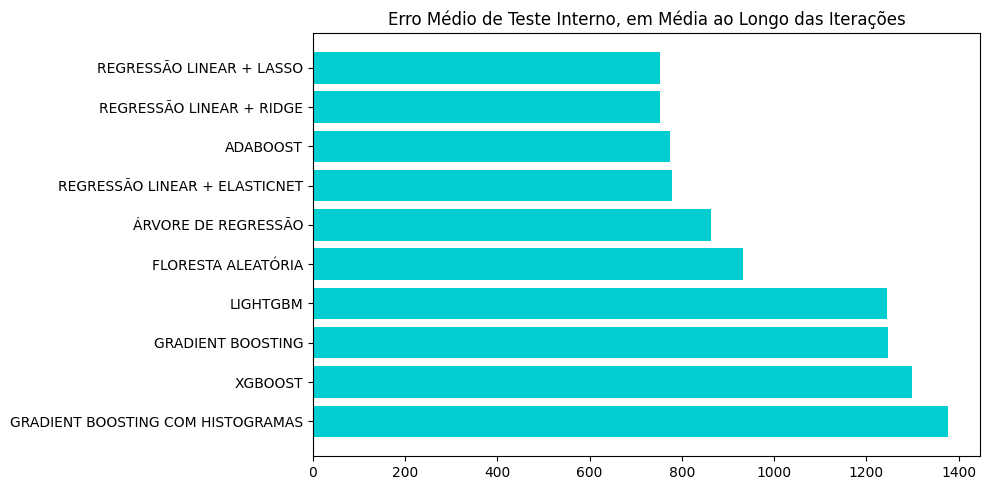

In [ ]:
# Gráfico do erro médio nos conjuntos de teste interno, em média ao longo das iterações do randomized search
resumo_algoritmos = (
    resultados
    .groupby("nome_algoritmo")["media_erro_teste_interno"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.barh(resumo_algoritmos.index, resumo_algoritmos.values, color="darkturquoise")
plt.title("Erro Médio de Teste Interno, em Média ao Longo das Iterações")
plt.tight_layout()
plt.show()

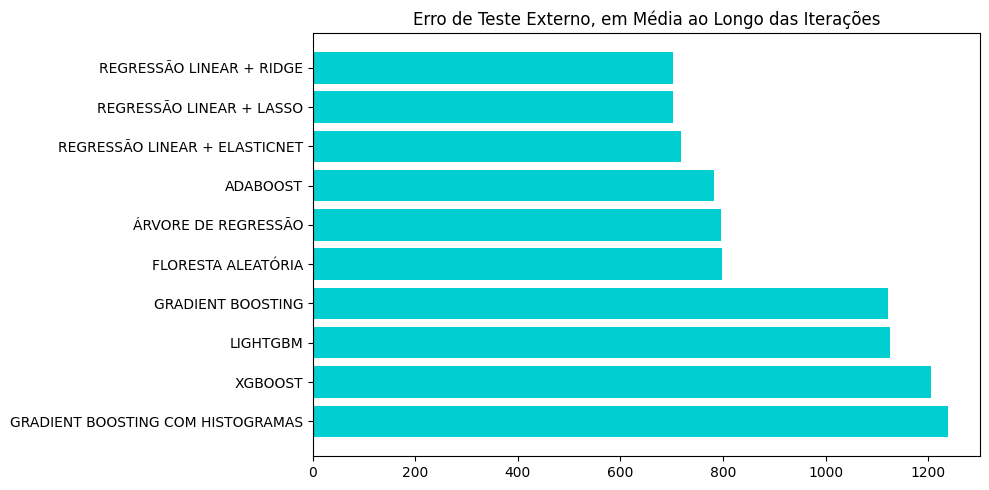

In [ ]:
# Gráfico do erro no conjunto de teste externo, em média ao longo das iterações do randomized search
resumo_algoritmos = (
    resultados
    .groupby("nome_algoritmo")["erro_teste_externo"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
plt.barh(resumo_algoritmos.index, resumo_algoritmos.values, color="darkturquoise")
plt.title("Erro de Teste Externo, em Média ao Longo das Iterações")
plt.tight_layout()
plt.show()

*Ordenação e filtragem dos melhores modelos*

In [ ]:
# Escolha por qual coluna ordenar
ordenar_por = "media_erro_teste_interno"
# ordenar_por = "var_abs_media_erro_teste_interno"
# ordenar_por = "var_abs_erro_teste_externo"

# Escolha quais o percentuais máximos de variação de erro (da média do treino para a média do teste interno; e da média do treino para o teste externo)
max_var_perc_erro_teste_interno = 0.1  # ex.: 0.1 representa 10%
max_var_perc_erro_teste_externo = 0.1

# Ordenação e filtragem
resultados_filt_ord = resultados[(resultados['var_abs_perc_media_erro_teste_interno'] < max_var_perc_erro_teste_interno) & (resultados['var_abs_perc_erro_teste_externo'] < max_var_perc_erro_teste_externo)]
resultados_filt_ord = resultados_filt_ord.sort_values(ordenar_por, ascending=True)

*Exibição dos melhores modelos, em formato de tabela e gráfico*

In [ ]:
pd.set_option('display.float_format', '{:.3f}'.format)   # Quantidade de casas decimais
resultados_filt_ord[['num_modelo',
                     'nome_algoritmo',
                     'hiperparametros',
                     'media_erro_treino',
                     'dp_erro_treino',
                     'media_erro_teste_interno',
                     'dp_erro_teste_interno',
                     'var_abs_media_erro_teste_interno',
                     'var_abs_perc_media_erro_teste_interno',
                     'erro_teste_externo',
                     'var_abs_erro_teste_externo',
                     'var_abs_perc_erro_teste_externo']].head(10)   # Escolha quantos modelos quer exibir

,num_modelo,nome_algoritmo,hiperparametros,media_erro_treino,dp_erro_treino,media_erro_teste_interno,dp_erro_teste_interno,var_abs_media_erro_teste_interno,var_abs_perc_media_erro_teste_interno,erro_teste_externo,var_abs_erro_teste_externo,var_abs_perc_erro_teste_externo
306,Modelo 306,GRADIENT BOOSTING,"{'learning_rate': 0.04673014179480298, 'max_de...",579.670,9.036,634.616,113.589,54.946,0.095,616.895,37.225,0.064
494,Modelo 494,LIGHTGBM,"{'learning_rate': 0.03148825485902, 'max_depth...",582.220,10.844,639.470,106.923,57.250,0.098,620.551,38.330,0.066
352,Modelo 352,GRADIENT BOOSTING COM HISTOGRAMAS,"{'l2_regularization': 0.002524911224859439, 'l...",586.207,12.749,641.266,113.517,55.060,0.094,619.988,33.782,0.058
392,Modelo 392,GRADIENT BOOSTING COM HISTOGRAMAS,"{'l2_regularization': 2.3807016406970794e-05, ...",618.096,10.870,650.339,117.798,32.243,0.052,629.785,11.689,0.019
472,Modelo 472,LIGHTGBM,"{'learning_rate': 0.018221241843911416, 'max_d...",617.438,11.796,651.966,113.898,34.527,0.056,631.708,14.270,0.023
387,Modelo 387,GRADIENT BOOSTING COM HISTOGRAMAS,"{'l2_regularization': 0.0002771214177043036, '...",609.343,12.199,655.102,125.055,45.759,0.075,619.666,10.322,0.017
376,Modelo 376,GRADIENT BOOSTING COM HISTOGRAMAS,"{'l2_regularization': 11.509360890386281, 'lea...",613.858,12.984,665.139,123.790,51.281,0.084,629.572,15.714,0.026
473,Modelo 473,LIGHTGBM,"{'learning_rate': 0.027109244279514107, 'max_d...",615.357,12.766,665.848,127.202,50.491,0.082,631.812,16.455,0.027
360,Modelo 360,GRADIENT BOOSTING COM HISTOGRAMAS,"{'l2_regularization': 0.02324046940849038, 'le...",627.075,11.632,671.539,132.021,44.464,0.071,635.466,8.391,0.013
322,Modelo 322,GRADIENT BOOSTING,"{'learning_rate': 0.03010338844193861, 'max_de...",623.773,12.920,673.849,129.400,50.075,0.080,647.633,23.859,0.038


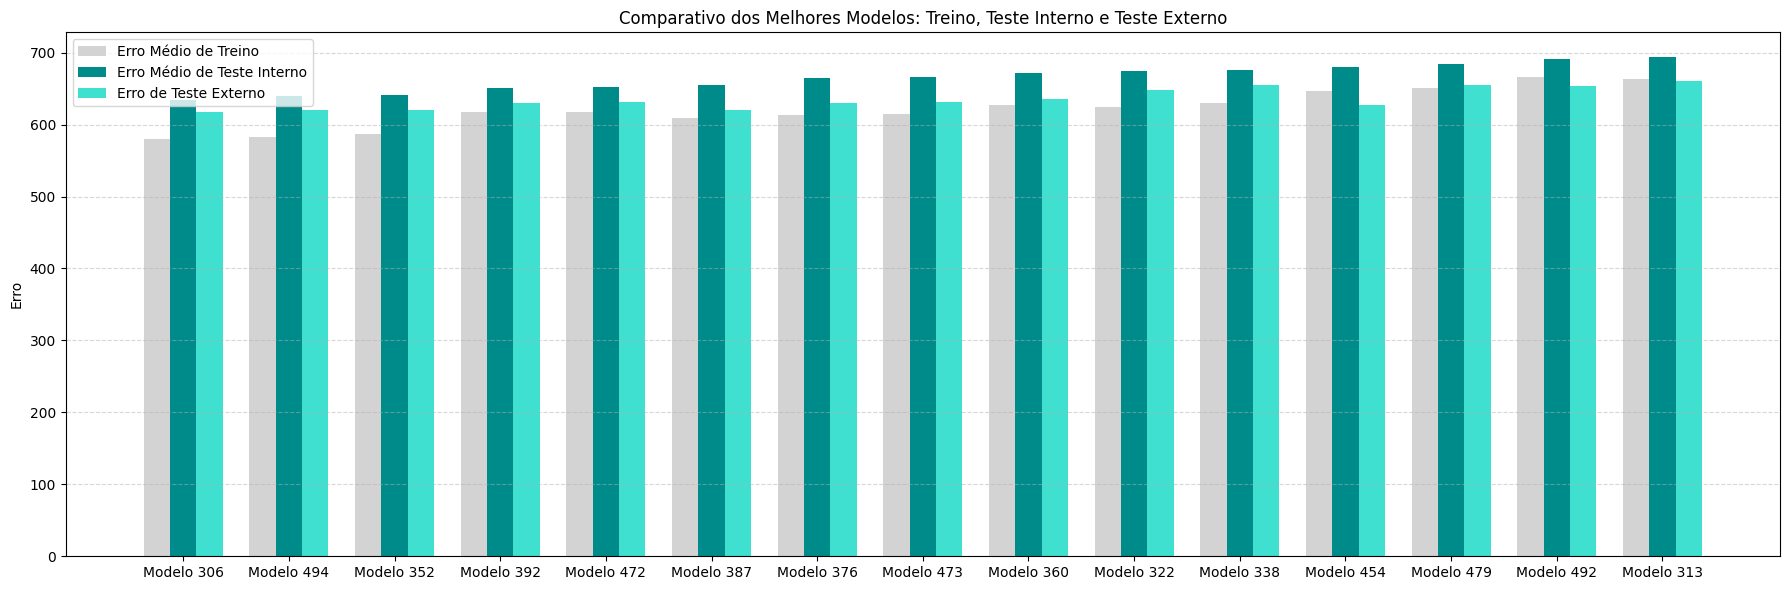

In [ ]:
dados_grafico = resultados_filt_ord.head(15)    # Escolha quantos modelos quer exibir
x_pos = np.arange(len(dados_grafico))           # Posições dos rótulos do eixo X
largura_barra = 0.25                            # Largura das barras

plt.figure(figsize=(18, 6))
plt.bar(x_pos - largura_barra,                  # Série com erro médio de treino
        dados_grafico["media_erro_treino"],
        width=largura_barra,
        label="Erro Médio de Treino",
        color="lightgray")
plt.bar(x_pos,                                  # Série com erro médio de teste interno
        dados_grafico["media_erro_teste_interno"],
        width=largura_barra,
        label="Erro Médio de Teste Interno",
        color="darkcyan")
plt.bar(x_pos + largura_barra,                  # Série com erro médio de teste externo
        dados_grafico["erro_teste_externo"],
        width=largura_barra,
        label="Erro de Teste Externo",
        color="turquoise")

plt.xticks(x_pos,
           dados_grafico["num_modelo"],
           rotation=0,
           ha='center')
plt.ylabel("Erro")
plt.title("Comparativo dos Melhores Modelos: Treino, Teste Interno e Teste Externo")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

*Escolha do modelo*

In [ ]:
num_modelo_escolhido = "Modelo 306"

*Características do modelo escolhido*

In [ ]:
linha = resultados.loc[resultados["num_modelo"] == num_modelo_escolhido].squeeze()
nome_algoritmo = linha["nome_algoritmo"]
hiperparametros = linha["hiperparametros"]
classe = algoritmos[nome_algoritmo][0]
print(f"O modelo final adotado foi construído com o algoritmo {nome_algoritmo}, com hiperparâmetros: { {k: round(v, 4) if isinstance(v, float) else v for k, v in hiperparametros.items()} }")

O modelo final adotado foi construído com o algoritmo GRADIENT BOOSTING, com hiperparâmetros: {'learning_rate': np.float64(0.0467), 'max_depth': 5, 'max_features': 'log2', 'min_impurity_decrease': np.float64(0.0347), 'min_samples_leaf': 56, 'min_samples_split': 126, 'n_estimators': 218, 'subsample': np.float64(0.721)}


*Retreino do modelo no conjunto de treino completo*

In [ ]:
modelo_final = classe.set_params(**hiperparametros)
modelo_final.fit(X_treino_tratada, y_treino)

GradientBoostingRegressor(learning_rate=np.float64(0.04673014179480298),
                          max_depth=5, max_features='log2',
                          min_impurity_decrease=np.float64(0.03467016218012572),
                          min_samples_leaf=56, min_samples_split=126,
                          n_estimators=218, random_state=123,
                          subsample=np.float64(0.7210197815814181))

#### Conclusão

O modelo final selecionado foi o Modelo 306, construído com o algoritmo Gradient Boosting. A escolha foi motivada pelo seu menor erro médio no teste externo e pela boa estabilidade entre os conjuntos de treino, teste interno e teste externo. Com um erro medio interno de 579,67, o modelo demonstrou alta capacidade de generalização, tornando-se o mais adequado para prever o valor que os clientes gastarão nos próximos 12 meses. Os hiperparâmetros otimizados para este modelo foram:

(1) learning_rate: 0.0467

(2) max_depth: 5

(3) max_features = 'log2'

(4) min_impurity_decrease: 0.0347

(5) min_samples_leaf: 56

(6) min_samples_split: 126

(7) n_estimators: 218

(8) random_state: 123

(9) subsample: 0.721

### **QUESTÃO 8**

#### **Análises adicionais no conjunto de teste externo**

*Aplicação do modelo final no conjunto de teste externo*

In [ ]:
y_hat_teste = modelo_final.predict(X_teste_tratada)

*Erro quadrático médio em raiz (RMSE)*

In [ ]:
np.sqrt(np.mean((y_teste - y_hat_teste)**2))

np.float64(616.8952288045674)

*Erro absoluto médio (MAE)*

In [ ]:
np.mean(np.abs(y_teste - y_hat_teste))

np.float64(398.60506607332735)

*Erro absoluto percentual médio (MAPE)*

In [ ]:
np.mean(np.abs((y_teste - y_hat_teste) / y))

np.float64(inf)

*Coeficiente de determinação (R²)*

In [ ]:
r2_score(y_teste, y_hat_teste)

0.8824112623629919

*Resíduos do modelo (e)*

In [ ]:
resid = y_teste - y_hat_teste

*Histograma dos resíduos*

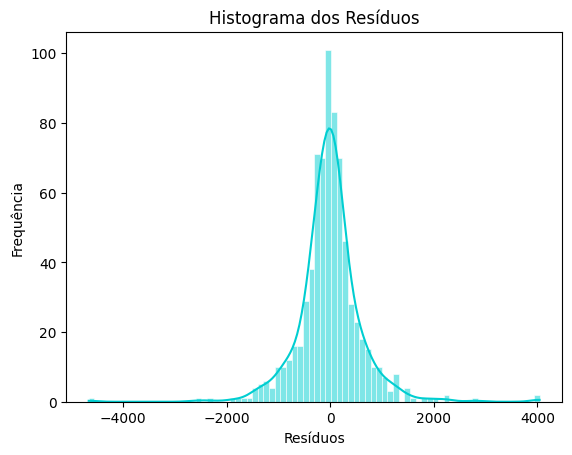

In [ ]:
sns.histplot(resid,
             color="darkturquoise",
             edgecolor="white",
             kde=True)
plt.title("Histograma dos Resíduos")
plt.xlabel("Resíduos")
plt.ylabel("Frequência")
plt.show()

*Gráfico de resíduos vs. valores preditos*

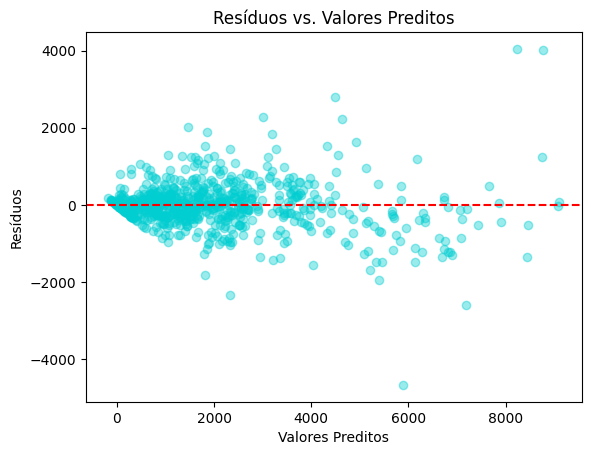

In [ ]:
plt.scatter(y_hat_teste,
            resid,
            color="darkturquoise",
            alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title("Resíduos vs. Valores Preditos")
plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos")
plt.show()

*Gráfico de valores observados vs. valores preditos da resposta*

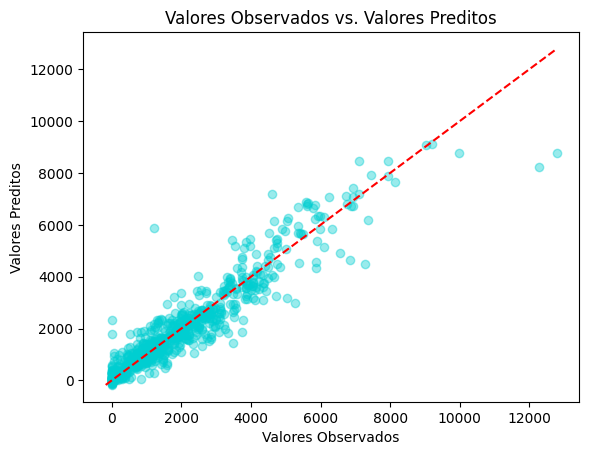

In [ ]:
min_eixo = min(y_teste.min(), y_hat_teste.min())
max_eixo = max(y_teste.max(), y_hat_teste.max())
plt.scatter(y_teste,
            y_hat_teste,
            color="darkturquoise",
            alpha=0.4)
plt.plot([min_eixo, max_eixo], [min_eixo, max_eixo], color='red', linestyle='--')
plt.title("Valores Observados vs. Valores Preditos")
plt.xlabel("Valores Observados")
plt.ylabel("Valores Preditos")
plt.show()

#### Conclusões

Analisando os indicadores de desempenho no teste externo, identifica-se que o erro de previsão do modelo é, em média, aproximadamente 616,89 reais (RMSE), com um erro absoluto médio de R$398,60 dos valores reais (MAE) para o valor gasto nos proximos 12 meses e com uma boa explicabilidade de 88,2% da variância dos dados de teste externo. Vale ressaltar que o MAPE resultou em infinito, sendo ocasionado pela divisão de valores por 0. Esse fato ocorre porque existem muitos clientes que não gastam nos próximos 12 meses (não aplicavel nestes casos).

Em relação aos residuos, observa-se que eles se distribuem de forma predominantemente simétria, sugerindo a distribuição normal, embora haja heterocedasticidade, já que os resíduos se dispersam mais à medida que os valores preditos aumentam. Por fim, o gráfico de valores observados vs. preditos revela que a maioria das previsões encontram-se próxima da linha de referência, reforçando a precisão do modelo.


### **QUESTÃO 9**

*Cálculo da importância em redução de impureza para cada variável no modelo final (aplicável apenas para modelos baseados em árvores)*

In [ ]:
# ATENÇÃO! Aplicável apenas caso o modelo final seja baseado em árvores; caso contrário, resultará em erro
importancias_impureza = pd.Series(modelo_final.feature_importances_,
                                  index=X_treino_tratada.columns).sort_values()

*Gráfico de importâncias em redução de impureza (aplicável apenas para modelos baseados em árvores)*

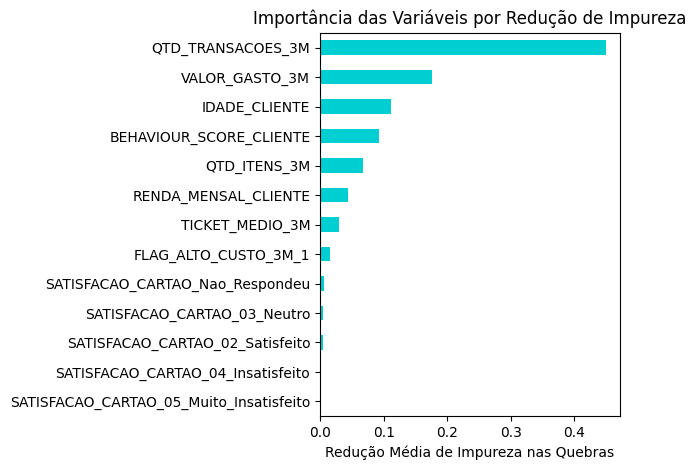

In [ ]:
# ATENÇÃO! Aplicável apenas caso o modelo final seja baseado em árvores; caso contrário, resultará em erro
importancias_impureza.plot.barh(title="Importância das Variáveis por Redução de Impureza",
                                  color="darkturquoise")
plt.xlabel("Redução Média de Impureza nas Quebras")
plt.tight_layout()
plt.show()

*Cálculo da importância via permutação para cada variável no modelo final*

In [ ]:
importancias_permutacao = permutation_importance(modelo_final,
                                                 X_treino_tratada,
                                                 y_treino,
                                                 n_repeats=30,
                                                 random_state=0,
                                                 scoring='neg_root_mean_squared_error')
importancias_permutacao = pd.Series(importancias_permutacao.importances_mean,
                                    index=X_treino_tratada.columns).sort_values()

*Gráfico de importâncias por permutação*

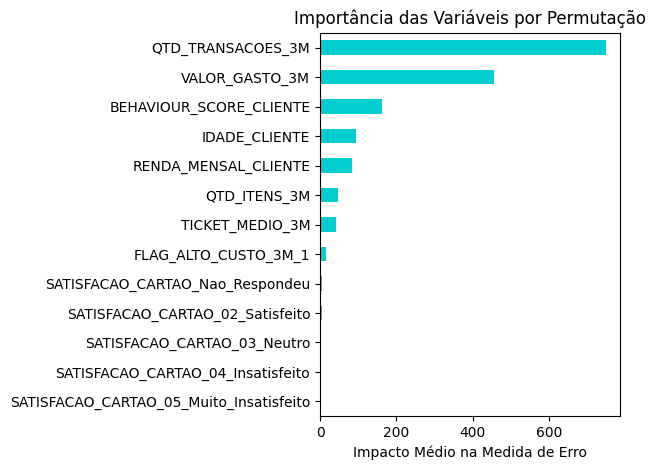

In [ ]:
importancias_permutacao.plot.barh(title="Importância das Variáveis por Permutação",
                                  color="darkturquoise")
plt.xlabel("Impacto Médio na Medida de Erro")
plt.tight_layout()
plt.show()

In [ ]:
if nome_algoritmo not in ['ADABOOST']:
    # Caso demore para rodar, especialmente em bases grandes, substitua X_treino_tratada.shape[0] por um número de tamanho de subamostra (ex.: 100)
    X_amostra = shap.sample(X_treino_tratada, X_treino_tratada.shape[0], random_state=123)
    explainer = shap.Explainer(modelo_final, X_amostra)
    valores_shap = explainer(X_amostra, check_additivity=False)
else:
    # Para AdaBoost, a implementação do cálculo de valores SHAP não é direta; é preciso usar um método mais oneroso computacionalmente, em uma subamostra pequena de observações
    X_amostra = shap.sample(X_treino_tratada, 100, random_state=123)
    explainer = shap.Explainer(modelo_final.predict, X_amostra)
    valores_shap = explainer(X_amostra, check_additivity=False)

 95%|=================== | 2088/2197 [00:14<00:00]       

*Gráfico de valores absolutos médios de SHAP*

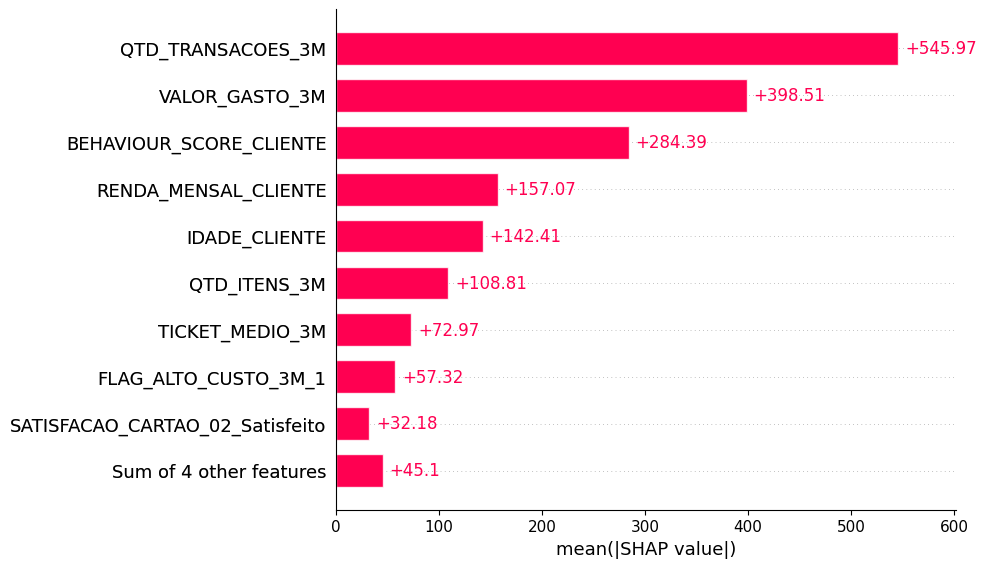

In [ ]:
shap.plots.bar(valores_shap)

#### Conclusão


As três abordagens anteriormente realizadas apresentam conclusões semelhantes, destacando especialmente as variáveis QTD_TRANSACOES_3M, VALOR_GASTO_3M, BEHAVIOUR_SCORE_CLIENTE, RENDA_MENSAL_CLIENTE, IDADE_CLIENTE e QTD_ITENS_3M como cruciais para a previsão do valor gasto nos próximos 12 meses. Apesar de haver variações na ordem de importância entre os métodos, todos atribuem o maior impacto à variável QTD_TRANSACOES_3M para o valor gasto.

### **QUESTÃO 10**

*Gráfico de direção do impacto baseado em SHAP (beeswarm)*

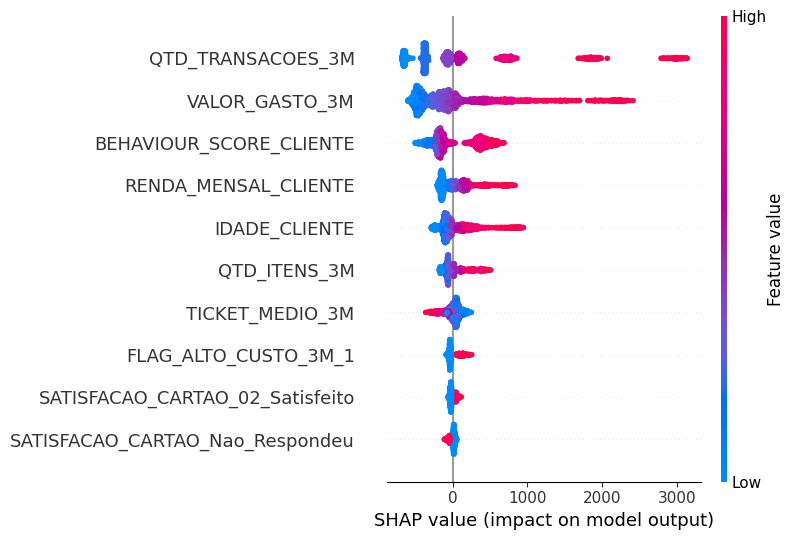

In [ ]:
shap.summary_plot(valores_shap, X_amostra, max_display=10)

#### Conclusões

Com base nos valores SHAP, observamos que as cinco variáveis com maior influência na predição do valor gasto pelos clientes nos 12 meses seguintes foram: QTD_TRANSACOES_3M, VALOR_GASTO_3M, BEHAVIOUR_SCORE_CLIENTE, RENDA_MENSAL_CLIENTE e IDADE_CLIENTE. De forma geral, valores mais altos nessas variáveis estão associados a gastos futuros mais elevados (maior impacto sobre o valor predito), o que está em linha com a análise bivariada e com a lógica de negócio. Os resultados reforçam que o comportamento inicial de consumo (quantidade de transações e valor gasto) e características do perfil do cliente (score, renda e idade) são fortes preditores do gasto futuro.